# Denoising Diffusion Probabilistic Model

In [1]:
import numpy as np
import torch 
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import gzip
import urllib.request as request
import os
import torch.optim as optim
import torchvision.datasets as datasets
import h5py
import time
import pandas as pd
import math
import random

from torch.optim import Adam
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from tqdm import tqdm
from torch.utils.data import Dataset, DataLoader, random_split
from torch.utils.data import Subset
from torchmetrics.image import StructuralSimilarityIndexMeasure


In [2]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device(
    "mps" if torch.backends.mps.is_available()
    else "cuda" if torch.cuda.is_available()
    else "cpu"
)

print("Device:", device)


Device: mps


In [3]:
class JetsDataset(Dataset):
    def __init__(self, file_path, percentile=99.5):
        with h5py.File(file_path, "r") as f:
            X = f["X_diffusion"][:].astype(np.float32)
            self.y = f["y"][:].astype(np.int64)

        print("ESTADÍSTICAS ORIGINALES")
        print("Shape:", X.shape)
        print("Min global:", X.min())
        print("Max global:", X.max())
        print("Mean global:", X.mean())
        print("Std global:", X.std())

        if X.min() < 0:
            X01 = (X + 1.0) / 2.0
        else:
            X01 = X.copy()
        X01 = np.clip(X01, 0.0, None)

        print("\n")
        print("DESPUÉS DE PASAR A [0, 1]")
        print("Min:", X01.min())
        print("Max:", X01.max())
        print("Mean:", X01.mean())
        print("Std:", X01.std())

        activos = X01[X01 > 0]

        if activos.size == 0:
            self.scale = 1.0
        else:
            self.scale = np.percentile(activos, percentile)

        print("\n" )
        print("ESCALA DE INTENSIDAD")
        print(f"Percentil activo {percentile}:", self.scale)

        X01 = X01 / (self.scale + 1e-8)
        X01 = np.clip(X01, 0.0, 1.0)

        X_scaled = 2.0 * X01 - 1.0

        self.X = X_scaled.astype(np.float32)

        print("ESTADÍSTICAS PARA ENTRENAR")
        print("Min global:", self.X.min())
        print("Max global:", self.X.max())
        print("Mean global:", self.X.mean())
        print("Std global:", self.X.std())

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        x = torch.from_numpy(self.X[idx]).float().permute(2, 0, 1)
        y = torch.tensor(self.y[idx], dtype=torch.long)
        return x, y

def inspeccionar_imagen(img, label=None):
    print("\n")
    print("IMAGEN")

    if label is not None:
        print("label =", label)

    print("shape =", img.shape)
    print("min =", img.min().item())
    print("max =", img.max().item())
    print("mean =", img.mean().item())
    print("std =", img.std().item())
    print("\n")
    print("RANGO POR CANAL")

    nombres = ["ECAL", "HCAL", "TRACKER"]

    for c, nombre in enumerate(nombres):
        canal = img[c]
        activos = canal[canal > -0.99]
        print(f"\n{nombre}")
        print("min total :", canal.min().item())
        print("max total :", canal.max().item())
        print("mean total:", canal.mean().item())
        print("std total :", canal.std().item())
        print("pix activos:", activos.numel(), "/", canal.numel())
        if activos.numel() > 0:
            print("min activo :", activos.min().item())
            print("max activo :", activos.max().item())
            print("mean activo:", activos.mean().item())
            print("std activo :", activos.std().item())

def visualizar_canales(img):
    img = img.detach().cpu()
    nombres = ["ECAL", "HCAL", "TRACKER"]
    fig, ax = plt.subplots(1, 3, figsize=(15, 5))
    for c, nombre in enumerate(nombres):
        im = ax[c].imshow(img[c].numpy(), origin="lower")
        ax[c].set_title(nombre)
        ax[c].axis("off")
        plt.colorbar(im, ax=ax[c], fraction=0.046)
    plt.tight_layout()
    plt.show()

def visualizar_rgb_jet(img, channel_order=(2, 0, 1), title="Jet RGB: R=Tracker, G=ECAL, B=HCAL", contrast=True):
    img = img.detach().cpu()
    img01 = (img + 1.0) / 2.0
    img01 = img01.clamp(0, 1)
    img01 = img01[list(channel_order)]
    if contrast:
        img_vis = img01.clone()
        for c in range(img_vis.shape[0]):
            canal = img_vis[c]
            activos = canal[canal > 1e-6]
            if activos.numel() > 0:
                vmax = torch.quantile(activos, 0.99)
                img_vis[c] = canal / (vmax + 1e-8)
        img_vis = img_vis.clamp(0, 1)
    else:
        img_vis = img01

    img_rgb = img_vis.permute(1, 2, 0).numpy()

    plt.figure(figsize=(6, 6))
    plt.imshow(img_rgb, origin="lower")
    plt.title(title)
    plt.axis("off")
    plt.show()

def visualizar_rgb_simple(img):
    img = img.detach().cpu()
    img_rgb = img.permute(1, 2, 0).numpy()
    img_rgb = (img_rgb + 1.0) / 2.0
    img_rgb = np.clip(img_rgb, 0, 1)

    plt.figure(figsize=(6, 6))
    plt.imshow(img_rgb, origin="lower")
    plt.title("Jet RGB simple")
    plt.axis("off")
    plt.show()

## Created the datasets 🗃️ 

We created a toy dataset for quick tests. If the full dataset is needed, set:
```python
subset_pequeno = True
```

We visualize a sample separately for the ECAL, HCAL, and tracker channels. We also visualize the combined image using a false-RGB representation, both with and without contrast enhancement.


ESTADÍSTICAS ORIGINALES
Shape: (139306, 64, 64, 3)
Min global: -1.0
Max global: 1.0
Mean global: -0.99999624
Std global: 0.002143081


DESPUÉS DE PASAR A [0, 1]
Min: 0.0
Max: 1.0
Mean: 6.293778e-05
Std: 0.0010698059


ESCALA DE INTENSIDAD
Percentil activo 99.5: 0.028265983
ESTADÍSTICAS PARA ENTRENAR
Min global: -1.0
Max global: 1.0
Mean global: -0.99695355
Std global: 0.051292248


IMAGEN
label = tensor(0)
shape = torch.Size([3, 64, 64])
min = -1.0
max = 1.0
mean = -0.9958806037902832
std = 0.03815007582306862


RANGO POR CANAL

ECAL
min total : -1.0
max total : 0.2988485097885132
mean total: -0.9970977306365967
std total : 0.031059639528393745
pix activos: 145 / 4096
min activo : -0.9896167516708374
max activo : 0.2988485097885132
mean activo: -0.9194411635398865
std activo : 0.14535829424858093

HCAL
min total : -1.0
max total : 1.0
mean total: -0.9945652484893799
std total : 0.04931170120835304
pix activos: 230 / 4096
min activo : -0.9899119734764099
max activo : 1.0
mean activo: -0

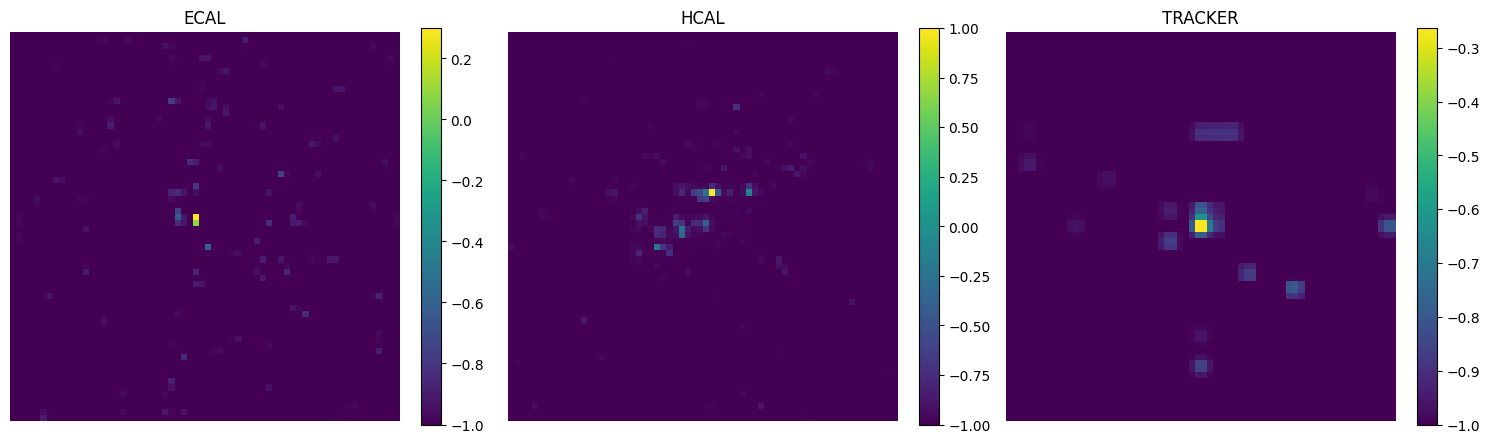

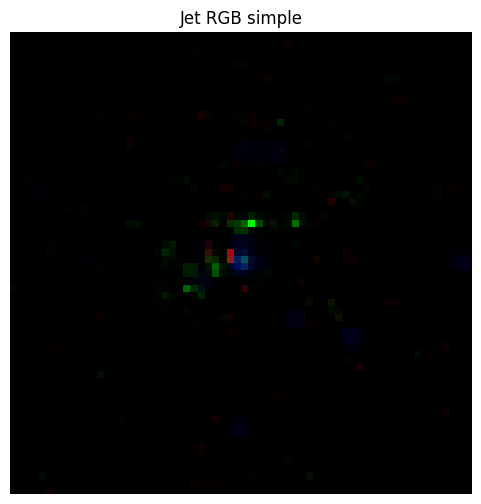

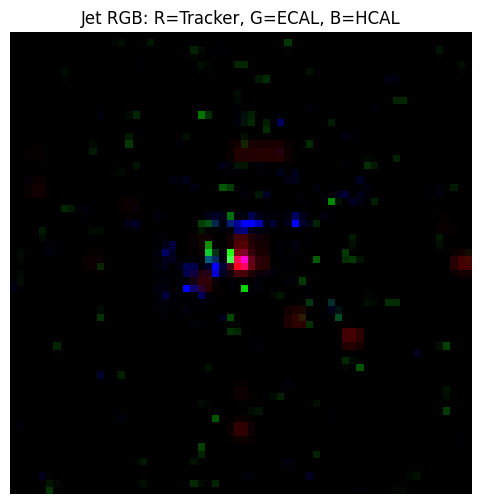

Train dataset usado: 10000
Test dataset usado : 2500
Val dataset usado : 2500


In [4]:
file_path = "Diffusion_jets_procesados_por_canal.hdf5"
full_dataset = JetsDataset(file_path)

img, label = full_dataset[0]
inspeccionar_imagen(img, label)
visualizar_canales(img)
visualizar_rgb_simple(img)
visualizar_rgb_jet(img)
total_size = len(full_dataset)
train_size = int(0.80 * total_size)
val_size = int(0.10 * total_size)
test_size = total_size - train_size - val_size

split_generator = torch.Generator().manual_seed(SEED)

train_dataset, val_dataset, test_dataset = random_split(full_dataset, [train_size, val_size, test_size], generator=split_generator,)

subset_pequeno = True #Change if the full dataset is needed

if subset_pequeno:
    train_small_size = 10000
    test_small_size = 2500
    val_small_size = 2500

    train_dataset = Subset(train_dataset, range(train_small_size))
    test_dataset = Subset(test_dataset, range(test_small_size))
    val_dataset = Subset(val_dataset, range(val_small_size))

print("Train dataset usado:", len(train_dataset))
print("Test dataset usado :", len(test_dataset))
print("Val dataset usado :", len(test_dataset))

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False, num_workers=0,)

x_batch, y_batch = next(iter(train_loader))

## Visualize several examples. 📸

To make the images clearer, we apply brightness and color adjustments:

* We ignore the black background.
* We clip extreme intensity values at the 99th percentile.
* We enhance each color channel independently.

These adjustments are used only for visualization and are not applied during model training.


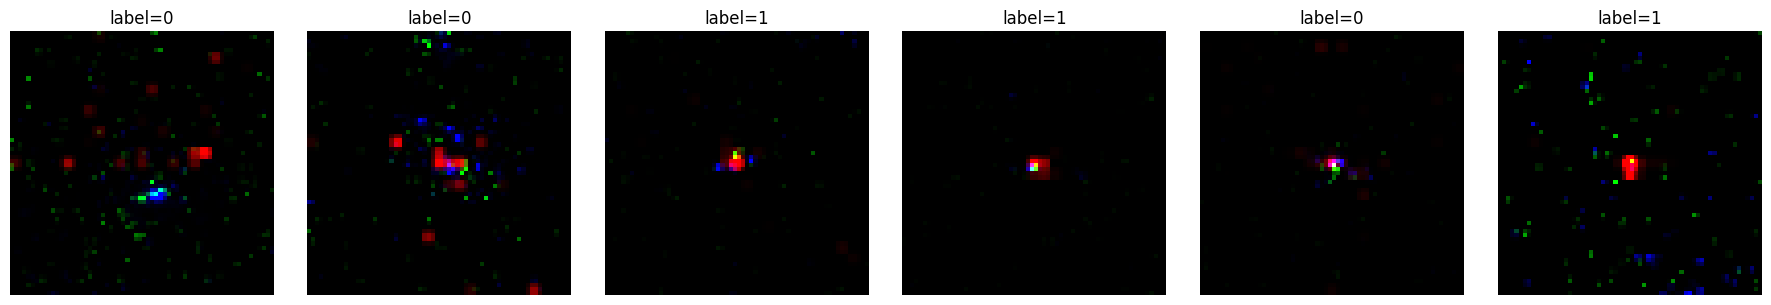

In [5]:
n = 6

fig, ax = plt.subplots(1, n, figsize=(3 * n, 3))

for i in range(n):

    img_i = x_batch[i].detach().cpu()
    img01 = (img_i + 1.0) / 2.0
    img01 = img01.clamp(0, 1)
    img01 = img01[[2, 0, 1]]
    img_vis = img01.clone()

    for c in range(3):
        canal = img_vis[c]
        activos = canal[canal > 1e-6]
        if activos.numel() > 0:
            vmax = torch.quantile(activos, 0.99)
            img_vis[c] = canal / (vmax + 1e-8)

    img_vis = img_vis.clamp(0, 1)
    img_rgb = img_vis.permute(1, 2, 0).numpy()

    ax[i].imshow(img_rgb, origin="lower")
    ax[i].set_title(f"label={y_batch[i].item()}")
    ax[i].axis("off")

plt.tight_layout()
plt.show()

In [6]:
#device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")


##  Linear Noise Scheduler 

The commented section corresponds to the change from epsilon prediction to v-prediction. It is not necessary for the rest of the program, but I kept it for clarity because I used it while developing the implementation.


In [7]:
class LinearNoiseScheduler:
    def __init__(self, num_timesteps, beta_s, beta_e, device):
        self.num_timesteps = num_timesteps
        self.beta_s = beta_s
        self.beta_e = beta_e
        self.device = device

        self.betas = torch.linspace(beta_s, beta_e, num_timesteps, device=device)
        self.alphas = 1.0 - self.betas
        self.alpha_cum_prod = torch.cumprod(self.alphas, dim=0)
        self.sqrt_alpha_cum_prod = torch.sqrt(self.alpha_cum_prod)
        self.sqrt_one_minus_alpha_cum_prod = torch.sqrt(1.0 - self.alpha_cum_prod)
        self.sqrt_recip_alphas = torch.sqrt(1.0 / self.alphas)
        alpha_cum_prod_prev = torch.cat([torch.tensor([1.0], device=device), self.alpha_cum_prod[:-1]], dim=0)
        self.posterior_variance = (self.betas * (1.0 - alpha_cum_prod_prev) / (1.0 - self.alpha_cum_prod))
        self.posterior_mean_coef1 = (self.betas * torch.sqrt(alpha_cum_prod_prev) / (1.0 - self.alpha_cum_prod))
        self.posterior_mean_coef2 = (torch.sqrt(self.alphas) * (1.0 - alpha_cum_prod_prev) / (1.0 - self.alpha_cum_prod))

    
    def sample_timesteps(self, batch_size):
        return torch.randint(0, self.num_timesteps, (batch_size,), device=self.device)

    def _extract(self, arr, t, x_shape):
        out = arr.gather(0, t)
        return out.view(t.shape[0], *([1] * (len(x_shape) - 1)))

    def add_noise(self, x0, t, noise=None):
        if noise is None:
            noise = torch.randn_like(x0)

        sqrt_alpha_cum_prod_t = self._extract(self.sqrt_alpha_cum_prod, t, x0.shape)
        sqrt_one_minus_alpha_cum_prod_t = self._extract(self.sqrt_one_minus_alpha_cum_prod, t, x0.shape)
        xt = sqrt_alpha_cum_prod_t * x0 + sqrt_one_minus_alpha_cum_prod_t * noise

        return xt, noise
    
    #Este bloque ya no es necesario, lo dejo por claridad personal.
    """
    @torch.no_grad()
    def sample_prev_timestep(self, xt, noise_pred, t):
        
        if isinstance(t, torch.Tensor):
            t_int = int(t.item())
        else:
            t_int = int(t)

        beta_t = self.betas[t_int]
        alpha_t = self.alphas[t_int]
        alpha_bar_t = self.alpha_cum_prod[t_int]

        sqrt_one_minus_alpha_bar_t = self.sqrt_one_minus_alpha_cum_prod[t_int]
        sqrt_alpha_bar_t = self.sqrt_alpha_cum_prod[t_int]

        x0_pred = (xt - sqrt_one_minus_alpha_bar_t * noise_pred) / sqrt_alpha_bar_t
        x0_pred = torch.clamp(x0_pred, -1.0, 1.0)

        mean = (xt - (beta_t / sqrt_one_minus_alpha_bar_t) * noise_pred)/torch.sqrt(alpha_t)

        if t_int == 0:
            return mean, x0_pred

        variance_t = self.posterior_variance[t_int]
        noise = torch.randn_like(xt)

        x_prev = mean + torch.sqrt(variance_t) * noise

        return x_prev, x0_pred
    
    """   
    @torch.no_grad()
    def sample_prev_timestep_v(self, xt, v_pred, t, clip_x0=True):
        
        if isinstance(t, torch.Tensor):
            t_int = int(t.item())
        else:
            t_int = int(t)

        sqrt_alpha_bar_t = self.sqrt_alpha_cum_prod[t_int]
        sqrt_one_minus_alpha_bar_t = self.sqrt_one_minus_alpha_cum_prod[t_int]
        x0_pred = sqrt_alpha_bar_t * xt - sqrt_one_minus_alpha_bar_t * v_pred

        if clip_x0:
            x0_pred = torch.clamp(x0_pred, -1.0, 1.0)

        if t_int == 0:
            return x0_pred, x0_pred

        posterior_mean = (self.posterior_mean_coef1[t_int] * x0_pred + self.posterior_mean_coef2[t_int] * xt)
        posterior_var = self.posterior_variance[t_int]
        noise = torch.randn_like(xt)
        x_prev = posterior_mean + torch.sqrt(posterior_var) * noise

        return x_prev, x0_pred
      

## Time Embedding

The time embedding informs the network about the current diffusion timestep and its corresponding noise level.

First, the timestep is converted into a sinusoidal vector using sine and cosine functions at different frequencies. This vector is then processed by a small MLP to produce a learnable representation.

The resulting embedding is injected into the network, allowing it to adapt its predictions at each stage of the diffusion process.


In [8]:
def get_num_groups(channels, max_groups=8):
    for g in reversed(range(1, max_groups + 1)):
        if channels % g == 0:
            return g
    return 1


def sinusoidal_time_embedding(timesteps, dim):
    if timesteps.dim() == 0:
        timesteps = timesteps[None]

    timesteps = timesteps.float()
    half_dim = dim // 2

    freqs = torch.exp(-math.log(10000) * torch.arange(half_dim, device=timesteps.device).float() / max(half_dim - 1, 1))

    args = timesteps[:, None] * freqs[None, :]
    emb = torch.cat([torch.sin(args), torch.cos(args)], dim=-1)

    if dim % 2 == 1:
        emb = F.pad(emb, (0, 1))

    return emb


class TimeEmbedding(nn.Module):
    def __init__(self, t_emb_dim):
        super().__init__()

        self.t_emb_dim = t_emb_dim

        self.mlp = nn.Sequential(
            nn.Linear(t_emb_dim, 4 * t_emb_dim),
            nn.SiLU(),
            nn.Linear(4 * t_emb_dim, t_emb_dim)
        )

    def forward(self, t):
        t_emb = sinusoidal_time_embedding(t, self.t_emb_dim)
        return self.mlp(t_emb)

## Building Blocks

We define the main components used to construct the U-Net architecture:

* Residual Block: processes features while preserving information through skip connections.
* Attention Block: helps the model capture long-range spatial relationships.
* Down Block: reduces the spatial resolution while increasing feature complexity.
* Up Block: restores the spatial resolution and combines features from the encoder through skip connections.

These blocks are later assembled to build the complete U-Net model.


In [9]:
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, t_emb_dim, dropout=0.0):
        super().__init__()

        self.norm1 = nn.GroupNorm(get_num_groups(in_channels), in_channels)
        self.conv1 = nn.Conv2d(
            in_channels,
            out_channels,
            kernel_size=3,
            padding=1
        )

        self.time_proj = nn.Sequential(
            nn.SiLU(),
            nn.Linear(t_emb_dim, 2 * out_channels)
        )

        self.norm2 = nn.GroupNorm(get_num_groups(out_channels), out_channels)
        self.dropout = nn.Dropout(dropout)

        self.conv2 = nn.Conv2d(
            out_channels,
            out_channels,
            kernel_size=3,
            padding=1
        )

        if in_channels != out_channels:
            self.skip = nn.Conv2d(in_channels, out_channels, kernel_size=1)
        else:
            self.skip = nn.Identity()

    def forward(self, x, t_emb):
        residual = self.skip(x)

        h = self.norm1(x)
        h = F.silu(h)
        h = self.conv1(h)

        scale_shift = self.time_proj(t_emb)
        scale, shift = scale_shift[:, :, None, None].chunk(2, dim=1)

        h = self.norm2(h)
        h = h * (1.0 + scale) + shift
        h = F.silu(h)
        h = self.dropout(h)
        h = self.conv2(h)

        return h + residual

In [10]:
class AttentionBlock(nn.Module):
    def __init__(self, channels, num_heads=4):
        super().__init__()

        assert channels % num_heads == 0

        self.num_heads = num_heads
        self.head_dim = channels // num_heads
        self.scale = self.head_dim ** -0.5

        self.norm = nn.GroupNorm(get_num_groups(channels), channels)
        self.qkv = nn.Conv2d(channels, 3 * channels, kernel_size=1)
        self.proj = nn.Conv2d(channels, channels, kernel_size=1)

    def forward(self, x):
        residual = x

        b, c, h, w = x.shape
        x = self.norm(x)

        q, k, v = self.qkv(x).chunk(3, dim=1)

        q = q.reshape(b, self.num_heads, self.head_dim, h * w)
        k = k.reshape(b, self.num_heads, self.head_dim, h * w)
        v = v.reshape(b, self.num_heads, self.head_dim, h * w)

        attn = torch.einsum("bhcn,bhcm->bhnm", q, k) * self.scale
        attn = attn.softmax(dim=-1)

        out = torch.einsum("bhnm,bhcm->bhcn", attn, v)
        out = out.reshape(b, c, h, w)

        return residual + self.proj(out)

In [11]:
class DownBlockStrong(nn.Module):
    def __init__(
        self,
        in_channels,
        out_channels,
        t_emb_dim,
        use_attention=False,
        dropout=0.0
    ):
        super().__init__()

        self.res1 = ResidualBlock(
            in_channels,
            out_channels,
            t_emb_dim,
            dropout=dropout
        )

        self.res2 = ResidualBlock(
            out_channels,
            out_channels,
            t_emb_dim,
            dropout=dropout
        )

        if use_attention:
            self.attn = AttentionBlock(out_channels)
        else:
            self.attn = nn.Identity()

        self.downsample = nn.Conv2d(
            out_channels,
            out_channels,
            kernel_size=4,
            stride=2,
            padding=1
        )

    def forward(self, x, t_emb, do_downsample=True):
        x = self.res1(x, t_emb)
        x = self.res2(x, t_emb)
        x = self.attn(x)

        skip = x

        if do_downsample:
            x = self.downsample(x)

        return x, skip

This block is no longer required, but I kept it in case it is needed again later.

In [12]:
class MidBlock(nn.Module):
    def __init__(self, in_channels, out_channels, t_emb_dim, num_heads=4):
        super().__init__()
        self.resnet1 = ResidualBlock(in_channels, out_channels, t_emb_dim)
        self.attn = AttentionBlock(out_channels, num_heads)
        self.resnet2 = ResidualBlock(out_channels, out_channels, t_emb_dim)

    def forward(self, x, t_emb):
        x = self.resnet1(x, t_emb)
        x = self.attn(x)
        
        return self.resnet2(x, t_emb)

In [13]:
class UpBlockStrong(nn.Module):
    def __init__(self, in_channels, skip_channels, out_channels, t_emb_dim, use_attention=False, dropout=0.0):
        super().__init__()

        self.res1 = ResidualBlock(
            in_channels + skip_channels,
            out_channels,
            t_emb_dim,
            dropout=dropout
        )

        self.res2 = ResidualBlock(
            out_channels,
            out_channels,
            t_emb_dim,
            dropout=dropout
        )

        if use_attention:
            self.attn = AttentionBlock(out_channels)
        else:
            self.attn = nn.Identity()

        self.upsample = nn.ConvTranspose2d(
            out_channels,
            out_channels,
            kernel_size=4,
            stride=2,
            padding=1
        )

    def forward(self, x, skip, t_emb, do_upsample=True):
        if x.shape[-2:] != skip.shape[-2:]:
            x = F.interpolate(x, size=skip.shape[-2:], mode="nearest")

        x = torch.cat([x, skip], dim=1)

        x = self.res1(x, t_emb)
        x = self.res2(x, t_emb)
        x = self.attn(x)

        if do_upsample:
            x = self.upsample(x)

        return x

## Building the U-Net 

We construct the U-Net using the previously defined residual, attention, downsampling, and upsampling blocks.

The network follows an encoder–decoder architecture with skip connections that preserve spatial information between corresponding resolutions. The timestep embedding is injected throughout the network to condition its predictions on the current diffusion step. Self-attention is applied at the (16 \times 16) and (8 \times 8) resolutions to capture global relationships. The model receives a three-channel (64 \times 64) image and produces an output with the same dimensions.

The design of this U-Net architecture was inspired by the work of Bansal et al., *Cold Diffusion: Inverting Arbitrary Image Transforms Without Noise*.


In [ ]:
class UNET(nn.Module):
    def __init__(self, im_channels=3, base_channels=64, channel_mults=(1, 2, 4, 4), t_emb_dim=256, img_size=64, attn_resolutions=(16, 8), dropout=0.0):
        super().__init__()

        self.img_size = img_size
        
        self.attn_resolutions = attn_resolutions

        self.time_mlp = TimeEmbedding(t_emb_dim)

        self.conv_in = nn.Conv2d(
            im_channels,
            base_channels,
            kernel_size=3,
            padding=1
        )
        channels = [base_channels * m for m in channel_mults]

        self.downs = nn.ModuleList()

        in_channels = base_channels
        resolution = img_size

        for i, out_channels in enumerate(channels):
            use_attention = resolution in attn_resolutions

            self.downs.append(
                DownBlockStrong(
                    in_channels=in_channels,
                    out_channels=out_channels,
                    t_emb_dim=t_emb_dim,
                    use_attention=use_attention,
                    dropout=dropout
                )
            )
            in_channels = out_channels

            if i != len(channels) - 1:
                resolution //= 2

        mid_channels = channels[-1]

        self.mid1 = ResidualBlock(
            mid_channels,
            mid_channels,
            t_emb_dim,
            dropout=dropout
        )

        self.mid_attn = AttentionBlock(mid_channels)

        self.mid2 = ResidualBlock(
            mid_channels,
            mid_channels,
            t_emb_dim,
            dropout=dropout
        )

        self.ups = nn.ModuleList()

        reversed_channels = list(reversed(channels))
        resolutions = [img_size // (2 ** i) for i in range(len(channels))]
        reversed_resolutions = list(reversed(resolutions))

        in_channels = mid_channels

        for i, skip_channels in enumerate(reversed_channels):
            is_last = i == len(reversed_channels) - 1

            if i < len(reversed_channels) - 1:
                out_channels = reversed_channels[i + 1]
            else:
                out_channels = base_channels

            use_attention = reversed_resolutions[i] in attn_resolutions

            self.ups.append(
                UpBlockStrong(
                    in_channels=in_channels,
                    skip_channels=skip_channels,
                    out_channels=out_channels,
                    t_emb_dim=t_emb_dim,
                    use_attention=use_attention,
                    dropout=dropout
                )
            )
            in_channels = out_channels

        self.norm_out = nn.GroupNorm(
            get_num_groups(base_channels),
            base_channels
        )

        self.conv_out = nn.Conv2d(
            base_channels,
            im_channels,
            kernel_size=3,
            padding=1
        )

    def forward(self, x, t):
        t_emb = self.time_mlp(t)

        x = self.conv_in(x)

        skips = []

        for i, down in enumerate(self.downs):
            do_downsample = i != len(self.downs) - 1
            x, skip = down(x, t_emb, do_downsample=do_downsample)
            skips.append(skip)

        x = self.mid1(x, t_emb)
        x = self.mid_attn(x)
        x = self.mid2(x, t_emb)

        for i, up in enumerate(self.ups):
            skip = skips.pop()
            do_upsample = i != len(self.ups) - 1
            x = up(x, skip, t_emb, do_upsample=do_upsample)

        x = self.norm_out(x)
        x = F.silu(x)

        return self.conv_out(x)

## Initial Configuration Parameters


In [15]:
configuracion_inicial = {
    "diffusion_params": {
        "num_timesteps": 1000,
        "beta_s": 1e-4,  
        "beta_e": 0.02    
    },

    "model_params": {
        "im_channels": 3,
        "im_size": 64
    },

    "train_params": {
        "task_name": "default",
        "batch_size": 64,   
        "num_epochs": 5,
        "num_samples": 100,
        "num_grid_rows": 10,
        "lr": 0.0001,
    }
}

## V-Prediction Loss with Background and Energy Terms

The loss function combines four components:

* Global loss: evaluates the overall accuracy of the (v)-prediction.
* Active-pixel loss: emphasizes pixels containing relevant jet information.
* Background loss: penalizes unwanted activity in background pixels.
* Energy loss: encourages the generated images to preserve the total energy of the real samples.

Each component is controlled by a weighting parameter ($\lambda$). The best results were obtained using:


$\lambda_{\text{active}} = 5, \qquad
\lambda_{\text{background}} = 100, \qquad
\lambda_{\text{energy}} = 10.$


In [16]:

def sparse_ddpm_v_loss_background_energy(v_pred,v_target, x_t, x0, t, scheduler, active_thr=-0.99, active_lambda=5.0, background_lambda=100.0, energy_lambda=10.0, bg_margin_01=0.0, eps=1e-8):
    
    # Loss de v-prediction
    error_v = (v_pred - v_target) ** 2
    loss_global = error_v.mean()
    active_mask = x0 > active_thr
    background_mask = x0 <= active_thr

    # Loss para active
    if active_mask.any():
        loss_active = error_v[active_mask].mean()
    else:
        loss_active = torch.tensor(0.0, device=x0.device)

    # Reconstrucción de v-prediction
    sqrt_alpha_bar_t = scheduler._extract(scheduler.sqrt_alpha_cum_prod, t, x0.shape)
    sqrt_one_minus_alpha_bar_t = scheduler._extract(scheduler.sqrt_one_minus_alpha_cum_prod, t, x0.shape)
    x0_pred = sqrt_alpha_bar_t * x_t - sqrt_one_minus_alpha_bar_t * v_pred

    x0_pred_01 = (x0_pred + 1.0) / 2.0
    x0_real_01 = (x0 + 1.0) / 2.0
    x0_pred_pos = torch.relu(x0_pred_01)

    # Penalización de fondo
    if background_mask.any():
        background_excess = torch.relu(x0_pred_01[background_mask] - bg_margin_01)
        loss_background = background_excess.mean()
    else:
        loss_background = torch.tensor(0.0, device=x0.device)

    # Penalización de energía total
    energy_pred = x0_pred_pos.sum(dim=(1, 2, 3))
    energy_real = x0_real_01.sum(dim=(1, 2, 3))
    
    loss_energy = F.mse_loss(torch.log1p(energy_pred), torch.log1p(energy_real))
    loss = (loss_global + active_lambda * loss_active + background_lambda * loss_background + energy_lambda * loss_energy)

    return loss, loss_global, loss_active, loss_background, loss_energy


## Evaluation Metrics 📊 

Here, we define the metrics required to evaluate the network.

The functions normalize the images to the ([0,1]) range and compare real, reconstructed, and generated jets using:

* MSE and SSIM to measure pixel-level similarity and structural quality.
* Wasserstein-1 distance to compare the spatial distributions along the (x) and (y) axes.
* Radial profiles to evaluate how the energy is distributed around the image center.
* Jet observables, including total energy, active-pixel fraction, maximum intensity, and participation ratio.
* Channel-wise metrics for ECAL, HCAL, and TRACKER.

Separate functions are used to evaluate reconstruction quality and generation quality, and the results are displayed in a table.


In [ ]:
CANAL_NOMBRES = ["ECAL", "HCAL", "TRACKER"]

@torch.no_grad()
def to_01(x):
    x = x.detach()
    if x.min().item() < -0.05:
        x = (x + 1.0) / 2.0
    return x.clamp(0.0, 1.0)

@torch.no_grad()
def wasserstein_xy_metric(x_pred, x_real, eps=1e-8):
    x_pred = to_01(x_pred)
    x_real = to_01(x_real)

    proj_x_pred = x_pred.sum(dim=1).sum(dim=1)  
    proj_x_real = x_real.sum(dim=1).sum(dim=1)  
    proj_y_pred = x_pred.sum(dim=1).sum(dim=2)  
    proj_y_real = x_real.sum(dim=1).sum(dim=2) 
    px_pred = proj_x_pred / (proj_x_pred.sum(dim=-1, keepdim=True) + eps)
    px_real = proj_x_real / (proj_x_real.sum(dim=-1, keepdim=True) + eps)
    py_pred = proj_y_pred / (proj_y_pred.sum(dim=-1, keepdim=True) + eps)
    py_real = proj_y_real / (proj_y_real.sum(dim=-1, keepdim=True) + eps)
    cdf_x_pred = torch.cumsum(px_pred, dim=-1)
    cdf_x_real = torch.cumsum(px_real, dim=-1)
    cdf_y_pred = torch.cumsum(py_pred, dim=-1)
    cdf_y_real = torch.cumsum(py_real, dim=-1)

    w1_x = torch.sum(torch.abs(cdf_x_pred - cdf_x_real), dim=-1).mean()
    w1_y = torch.sum(torch.abs(cdf_y_pred - cdf_y_real), dim=-1).mean()

    return {"w1_x": w1_x.item(), "w1_y": w1_y.item(), "w1_xy": (w1_x + w1_y).item()}


class JetRadialProfiler(nn.Module):
    
    def __init__(self, img_size=64, num_bins=32, sigma=1.0):
        super().__init__()

        self.num_bins = num_bins
        self.sigma = sigma

        y = torch.arange(img_size).float()
        x = torch.arange(img_size).float()

        grid_y, grid_x = torch.meshgrid(y, x, indexing="ij")

        cy = img_size / 2 - 0.5
        cx = img_size / 2 - 0.5

        dist_matrix = torch.sqrt((grid_y - cy) ** 2 + (grid_x - cx) ** 2)
        max_r = float(dist_matrix.max().item())
        bin_centers = torch.linspace(0.0, max_r, num_bins)
        self.register_buffer("dist_matrix", dist_matrix.view(1, 1, img_size, img_size))
        self.register_buffer("bin_centers", bin_centers.view(1, 1, 1, 1, num_bins))

    def profiles(self, x):
        
        x = to_01(x)
        B, C, H, W = x.shape
        dists = self.dist_matrix.expand(B, C, H, W).unsqueeze(-1)
        weights = torch.exp(-0.5 * ((dists - self.bin_centers) / self.sigma) ** 2)
        profile = (x.unsqueeze(-1) * weights).sum(dim=(2, 3))
        profile = profile / (profile.sum(dim=-1, keepdim=True) + 1e-8)
        return profile

    def forward(self, x_pred, x_real):
        profile_pred = self.profiles(x_pred)
        profile_real = self.profiles(x_real)

        return F.mse_loss(profile_pred, profile_real)


@torch.no_grad()
def jet_observables(x, active_thr=1e-4, eps=1e-8):
    x = to_01(x)
    energy = x.sum(dim=(1, 2, 3))
    active_frac = (x > active_thr).float().mean(dim=(1, 2, 3))
    max_intensity = x.amax(dim=(1, 2, 3))
    participation_ratio = (energy ** 2) / ((x ** 2).sum(dim=(1, 2, 3)) + eps)
    return {"energy": energy, "active_frac": active_frac, "max_intensity": max_intensity, "participation_ratio": participation_ratio}


def w1_samples(a, b, num_quantiles=1000):
    a = a.detach().float().cpu().numpy().reshape(-1)
    b = b.detach().float().cpu().numpy().reshape(-1)
    nq = min(num_quantiles, len(a), len(b))
    qs = np.linspace(0.0, 1.0, nq)
    qa = np.quantile(a, qs)
    qb = np.quantile(b, qs)

    return float(np.mean(np.abs(qa - qb)))

@torch.no_grad()
def evaluar_reconstruccion_jets(x_rec, x_real, active_thr=1e-4, num_bins=32):
    x_rec = to_01(x_rec)
    x_real = to_01(x_real)

    device_metric = x_real.device
    metricas = {}
    metricas["mse_total"] = F.mse_loss(x_rec, x_real).item()
    active_mask = x_real > active_thr

    if active_mask.sum() > 0:
        metricas["mse_activo_real"] = ((x_rec - x_real) ** 2)[active_mask].mean().item()
    else:
        metricas["mse_activo_real"] = np.nan

    ssim_metric = StructuralSimilarityIndexMeasure(data_range=1.0).to(device_metric)
    metricas["ssim"] = ssim_metric(x_rec, x_real).item()
    metricas.update(wasserstein_xy_metric(x_rec, x_real))
    radial = JetRadialProfiler(img_size=x_real.shape[-1], num_bins=num_bins, sigma=1.0).to(device_metric)
    metricas["radial_mse"] = radial(x_rec, x_real).item()
    obs_real = jet_observables(x_real, active_thr=active_thr)
    obs_rec = jet_observables(x_rec, active_thr=active_thr)

    for key in obs_real:
        metricas[f"{key}_real_mean"] = obs_real[key].mean().item()
        metricas[f"{key}_rec_mean"] = obs_rec[key].mean().item()

    for c, nombre in enumerate(CANAL_NOMBRES):
        xr_c = x_real[:, c:c+1]
        xp_c = x_rec[:, c:c+1]

        metricas[f"mse_{nombre}"] = F.mse_loss(xp_c, xr_c).item()

        w1_c = wasserstein_xy_metric(xp_c, xr_c)
        metricas[f"w1_xy_{nombre}"] = w1_c["w1_xy"]
    return metricas

@torch.no_grad()
def evaluar_generacion_jets(x_gen, x_real_ref, active_thr=1e-4, num_bins=32):
    
    x_gen = to_01(x_gen)
    x_real_ref = to_01(x_real_ref).to(x_gen.device)

    device_metric = x_gen.device
    metricas = {}
    obs_real = jet_observables(x_real_ref, active_thr=active_thr)
    obs_gen = jet_observables(x_gen, active_thr=active_thr)

    metricas["E_w1"] = w1_samples(obs_gen["energy"], obs_real["energy"])
    metricas["active_frac_w1"] = w1_samples(obs_gen["active_frac"], obs_real["active_frac"])
    metricas["max_intensity_w1"] = w1_samples(obs_gen["max_intensity"], obs_real["max_intensity"])
    metricas["participation_ratio_w1"] = w1_samples(obs_gen["participation_ratio"], obs_real["participation_ratio"])
    metricas["energy_real_mean"] = obs_real["energy"].mean().item()
    metricas["energy_gen_mean"] = obs_gen["energy"].mean().item()
    metricas["active_frac_real_mean"] = obs_real["active_frac"].mean().item()
    metricas["active_frac_gen_mean"] = obs_gen["active_frac"].mean().item()
    metricas["max_real_mean"] = obs_real["max_intensity"].mean().item()
    metricas["max_gen_mean"] = obs_gen["max_intensity"].mean().item()
    metricas["pr_real_mean"] = obs_real["participation_ratio"].mean().item()
    metricas["pr_gen_mean"] = obs_gen["participation_ratio"].mean().item()
    metricas["pr_ratio"] = metricas["pr_gen_mean"] / (metricas["pr_real_mean"] + 1e-8)
    metricas["gen_max_to_real_max"] = (x_gen.amax().item() / (x_real_ref.amax().item() + 1e-8))

    radial = JetRadialProfiler(img_size=x_real_ref.shape[-1],num_bins=num_bins,sigma=1.0).to(device_metric)

    prof_real = radial.profiles(x_real_ref).mean(dim=0)
    prof_gen = radial.profiles(x_gen).mean(dim=0)
    metricas["radial_l2"] = torch.sqrt(torch.mean((prof_gen - prof_real) ** 2)).item()
    metricas["radial_l2_log"] = torch.sqrt(torch.mean((torch.log10(prof_gen + 1e-8) - torch.log10(prof_real + 1e-8)) ** 2)).item()

    return metricas

@torch.no_grad()
def obtener_reales_01(loader, n, device):
    xs = []
    total = 0
    for im, _ in loader:
        xs.append(im.float())
        total += im.shape[0]

        if total >= n:
            break

    x = torch.cat(xs, dim=0)[:n].to(device)

    return to_01(x)

def mostrar_metricas(metricas, titulo="Métricas"):
    print("\n" )
    print(titulo)
    print("\n" )

    df = pd.DataFrame.from_dict(metricas, orient="index", columns=["valor"])
    display(df)

## Training with V-Prediction, Background, and Energy Losses

We train the model using v-prediction and the complete loss function, which combines global, active-pixel, background, and energy terms. This encourages accurate predictions while reducing unwanted background activity and preserving the total jet energy.


In [18]:
def train_v_prediction_background_energy():
    device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
    diffusion_config = configuracion_inicial["diffusion_params"]
    model_config = configuracion_inicial["model_params"]
    train_config = configuracion_inicial["train_params"]
    scheduler = LinearNoiseScheduler(num_timesteps=diffusion_config["num_timesteps"], beta_s=diffusion_config["beta_s"], beta_e=diffusion_config["beta_e"], device=device)

    print("SCHEDULER PARA V-PREDICTION CON BACKGROUND + ENERGY LOSS\n")
    print("num_timesteps:", scheduler.num_timesteps)
    print("beta min:", scheduler.betas.min().item())
    print("beta max:", scheduler.betas.max().item())
    print("sqrt_alpha final:", scheduler.sqrt_alpha_cum_prod[-1].item())
    print("sqrt_noise final:", scheduler.sqrt_one_minus_alpha_cum_prod[-1].item())

    model = UNET(model_config["im_channels"]).to(device)
    model.train()
    optimizer = Adam(model.parameters(), lr=train_config["lr"])
    num_epochs = train_config["num_epochs"]

    for epoch_idx in range(num_epochs):
        losses = []
        global_losses = []
        active_losses = []
        background_losses = []
        energy_losses = []
        start_time = time.time()

        for step, (im, _) in enumerate(train_loader):
            im = im.float().to(device)
            optimizer.zero_grad()
            noise = torch.randn_like(im)
            t = scheduler.sample_timesteps(im.shape[0])
            t = t.to(device)
            noisy_im, noise = scheduler.add_noise(im, t, noise)

            sqrt_alpha_bar_t = scheduler._extract(scheduler.sqrt_alpha_cum_prod, t, im.shape)
            sqrt_one_minus_alpha_bar_t = scheduler._extract(scheduler.sqrt_one_minus_alpha_cum_prod, t, im.shape)
            v_target = sqrt_alpha_bar_t * noise - sqrt_one_minus_alpha_bar_t * im
            v_pred = model(noisy_im, t)

            loss, loss_global, loss_active, loss_background, loss_energy = sparse_ddpm_v_loss_background_energy(v_pred=v_pred, v_target=v_target, x_t=noisy_im, x0=im, t=t, scheduler=scheduler, active_thr=-0.99, active_lambda=5.0, background_lambda=100.0, energy_lambda=10.0, bg_margin_01=0.0)

            loss.backward()
            optimizer.step()
            losses.append(loss.item())
            global_losses.append(loss_global.item())
            active_losses.append(loss_active.item())
            background_losses.append(loss_background.item())
            energy_losses.append(loss_energy.item())

        elapsed = time.time() - start_time
        print(f"Epoch: {epoch_idx+1}/{num_epochs} | Loss: {np.mean(losses):.6f} | Global: {np.mean(global_losses):.6f} | Active: {np.mean(active_losses):.6f} | Background: {np.mean(background_losses):.6f} | Energy: {np.mean(energy_losses):.6f} | Time: {elapsed:.2f}s")

    return model, scheduler

In [19]:
model = UNET(
    im_channels=3,
    base_channels=64,
    channel_mults=(1, 2, 4, 4),
    t_emb_dim=256,
    img_size=64,
    attn_resolutions=(16, 8),
    dropout=0.0
).to(device)

In [20]:
num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Parámetros entrenables: {num_params:,}")

Parámetros entrenables: 19,183,619


We train the model.

In [21]:
modelo_entrenado, scheduler= train_v_prediction_background_energy()

SCHEDULER PARA V-PREDICTION CON BACKGROUND + ENERGY LOSS

num_timesteps: 1000
beta min: 9.999999747378752e-05
beta max: 0.019999999552965164
sqrt_alpha final: 0.0063528153114020824
sqrt_noise final: 0.9999797940254211
Epoch: 1/5 | Loss: 7.724417 | Global: 0.428614 | Active: 0.519400 | Background: 0.004338 | Energy: 0.426500 | Time: 127.79s
Epoch: 2/5 | Loss: 2.114116 | Global: 0.111097 | Active: 0.212049 | Background: 0.001322 | Energy: 0.081060 | Time: 125.45s
Epoch: 3/5 | Loss: 1.914554 | Global: 0.084291 | Active: 0.186089 | Background: 0.001183 | Energy: 0.078156 | Time: 124.01s
Epoch: 4/5 | Loss: 1.835462 | Global: 0.076729 | Active: 0.175954 | Background: 0.001106 | Energy: 0.076833 | Time: 122.83s
Epoch: 5/5 | Loss: 1.818761 | Global: 0.068412 | Active: 0.165957 | Background: 0.001115 | Energy: 0.080903 | Time: 122.91s


## Jet Generation

To evaluate how well the network has learned the data distribution, we generate jets from noise. Starting from a random noisy image, the model iteratively denoises it step by step using the scheduler until it produces a final jet image. In this implementation, generation is performed with v-prediction.

The commented line corresponds to the previous epsilon-prediction version, so it can be safely left commented for reference.

For visualization, the generated images are converted to a false-RGB representation and can optionally include contrast enhancement. These display adjustments are only used for visualization and do not affect the generated data itself.


In [22]:
@torch.no_grad()
def generar_jets(model, scheduler, num_imagenes=4, shape=(3, 64, 64), mostrar=True, max_mostrar=6, contrast=True):
    model.eval()
    device = next(model.parameters()).device

    x = torch.randn((num_imagenes, *shape), device=device)

    x0_pred_final = None

    for t in reversed(range(scheduler.num_timesteps)):
        t_tensor = torch.full( (num_imagenes,), t, device=device, dtype=torch.long)
        noise_pred = model(x, t_tensor)

        #x, x0_pred = scheduler.sample_prev_timestep(x, noise_pred, t) #MODIFICAR 
        x, x0_pred = scheduler.sample_prev_timestep_v(x, noise_pred, t) #MODIFICAR 

        if t == 0:
            x0_pred_final = x0_pred

    imgs = (x0_pred_final + 1.0) / 2.0
    imgs = torch.clamp(imgs, 0.0, 1.0)
    imgs = imgs.cpu()

    if mostrar:
        n_vis = min(num_imagenes, max_mostrar)
        fig, axes = plt.subplots(1, n_vis, figsize=(3 * n_vis, 3))
        if n_vis == 1:
            axes = [axes]
        for i in range(n_vis):
            img = imgs[i].clone()

            # R=TRACKER, G=ECAL, B=HCAL
            img = img[[2, 0, 1]]
            if contrast:
                for c in range(3):
                    canal = img[c]
                    activos = canal[canal > 1e-6]

                    if activos.numel() > 0:
                        vmax = torch.quantile(activos, 0.99)
                        img[c] = canal / (vmax + 1e-8)

            img = img.clamp(0, 1)
            img_rgb = img.permute(1, 2, 0).numpy()
            axes[i].imshow(img_rgb, origin="lower")
            axes[i].axis("off")
        plt.tight_layout()
        plt.show()

    return imgs

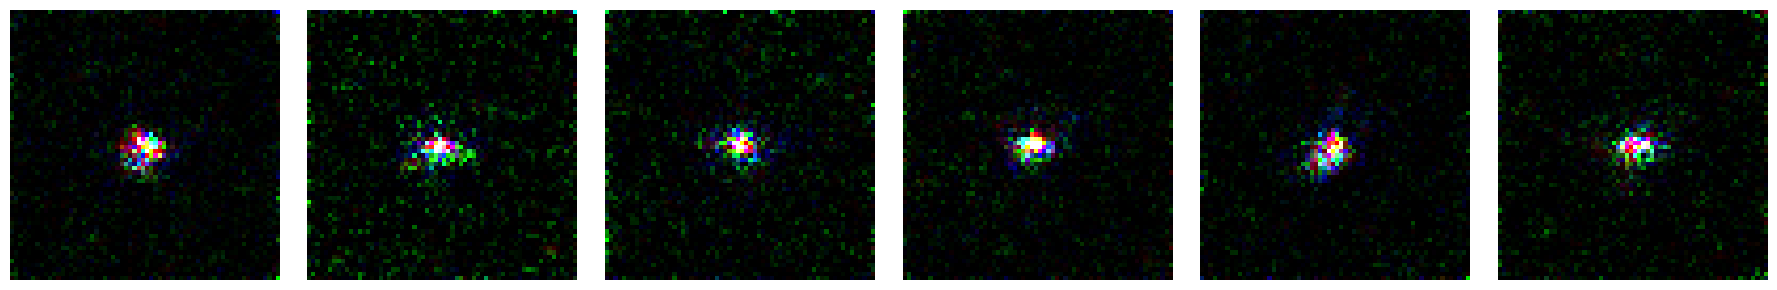

In [23]:
imgs = generar_jets(modelo_entrenado, scheduler, num_imagenes=6, shape=(3, 64, 64), mostrar=True, contrast=True)

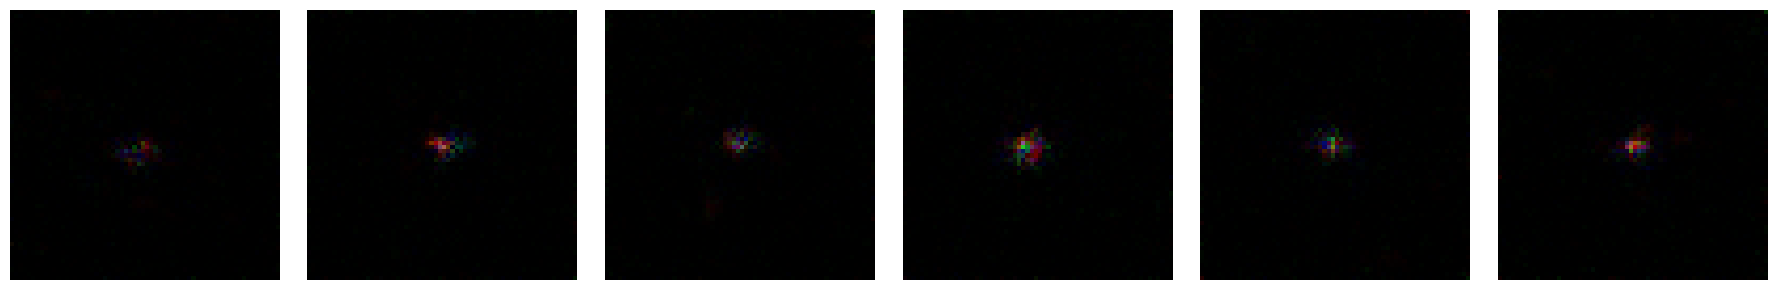

In [24]:
imgs_2 = generar_jets(modelo_entrenado, scheduler, num_imagenes=6, shape=(3, 64, 64), mostrar=True, contrast=False)

## Comparison

We generate 128 jets and compare them with real jet samples using the previously defined evaluation metrics. The reported values correspond to averages over the evaluated samples.

In [25]:
n_eval_gen = 128

jets_gen_eval = generar_jets(modelo_entrenado, scheduler, num_imagenes=n_eval_gen, shape=(3, 64, 64), mostrar=False, contrast=False)
jets_real_eval = obtener_reales_01(test_loader, n=n_eval_gen, device=jets_gen_eval.device)
metricas_gen = evaluar_generacion_jets(jets_gen_eval, jets_real_eval, active_thr=1e-4, num_bins=32)

mostrar_metricas(metricas_gen, titulo="Generación con DDPM")



Generación con DDPM




,valor
E_w1,24.692622
active_frac_w1,0.330591
max_intensity_w1,0.216261
participation_ratio_w1,332.878051
energy_real_mean,25.038284
energy_gen_mean,49.730904
active_frac_real_mean,0.044781
active_frac_gen_mean,0.375372
max_real_mean,0.920021
max_gen_mean,0.703760


## Reconstruction Visualization

We reconstruct real jet images from different starting timesteps to evaluate how well the model can recover the original data after adding different amounts of noise.

For each selected timestep, the function:

* Adds noise to the original image to obtain (x_t).
* Iteratively denoises the image using v-prediction.
* Displays the original, degraded, and reconstructed images.
* Computes and prints the reconstruction MSE.

This allows us to visually and quantitatively study how reconstruction quality changes as the starting timestep increases.


In [28]:
@torch.no_grad()
def reconstruccion_iterativa_desde_xt_ddpm(model, scheduler, loader, device, t_start=50, n=4, mostrar=True, contrast=True):
    model.eval()
    x0, _ = next(iter(loader))
    x0 = x0[:n].float().to(device)
    noise = torch.randn_like(x0)
    t_start_tensor = torch.full((n,), t_start, device=device, dtype=torch.long)
    x_t, noise_real = scheduler.add_noise(x0, t_start_tensor, noise)
    x = x_t.clone()
    x0_pred_final = None

    for t in reversed(range(t_start + 1)):
        t_batch = torch.full((n,), t, device=device, dtype=torch.long)
        noise_pred = model(x, t_batch)
        #x, x0_pred = scheduler.sample_prev_timestep(x, noise_pred, t) #Modificar
        x, x0_pred = scheduler.sample_prev_timestep_v(x, noise_pred, t) #Modificar
        x0_pred_final = x0_pred

    x0_pred_final = torch.clamp(x0_pred_final, -1.0, 1.0)
    x0_vis = torch.clamp((x0 + 1.0) / 2.0, 0.0, 1.0).cpu()
    xt_vis = torch.clamp((x_t + 1.0) / 2.0, 0.0, 1.0).cpu()
    recon_vis = torch.clamp((x0_pred_final + 1.0) / 2.0, 0.0, 1.0).cpu()

    if mostrar:
        fig, axes = plt.subplots(n, 3, figsize=(9, 3 * n))

        if n == 1:
            axes = [axes]

        for i in range(n):
            img0 = x0_vis[i][[2, 0, 1]].permute(1, 2, 0).numpy()
            imgt = xt_vis[i][[2, 0, 1]].permute(1, 2, 0).numpy()
            imgr = recon_vis[i][[2, 0, 1]].permute(1, 2, 0).numpy()

            axes[i][0].imshow(img0, origin="lower")
            axes[i][0].set_title("Original")
            axes[i][0].axis("off")
            axes[i][1].imshow(imgt, origin="lower")
            axes[i][1].set_title(f"Degradada x_t, t={t_start}")
            axes[i][1].axis("off")
            axes[i][2].imshow(imgr, origin="lower")
            axes[i][2].set_title("Reconstrucción")
            axes[i][2].axis("off")
        plt.tight_layout()
        plt.show()

    return {"x0": x0.detach().cpu(), "x_t": x_t.detach().cpu(), "recon": x0_pred_final.detach().cpu(), "x0_01": x0_vis, "xt_01": xt_vis, "recon_01": recon_vis, "t_start": t_start}

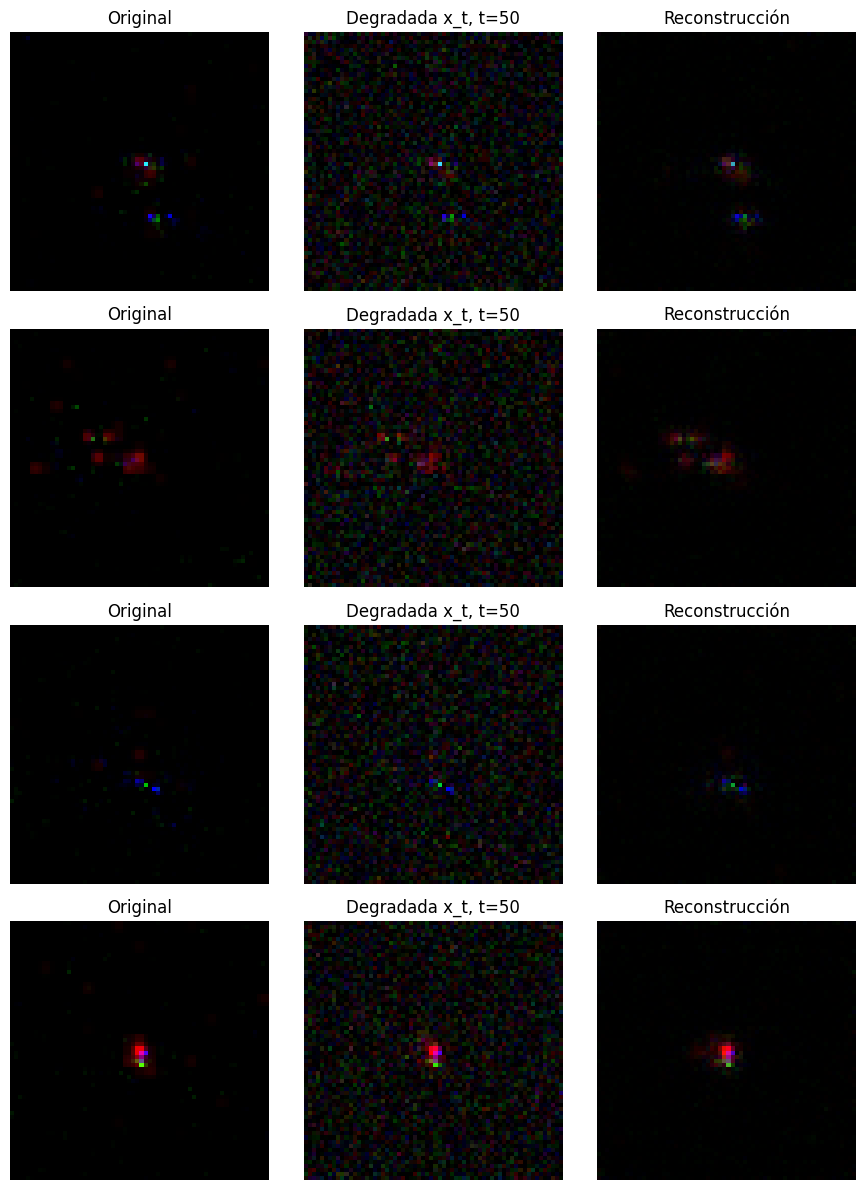

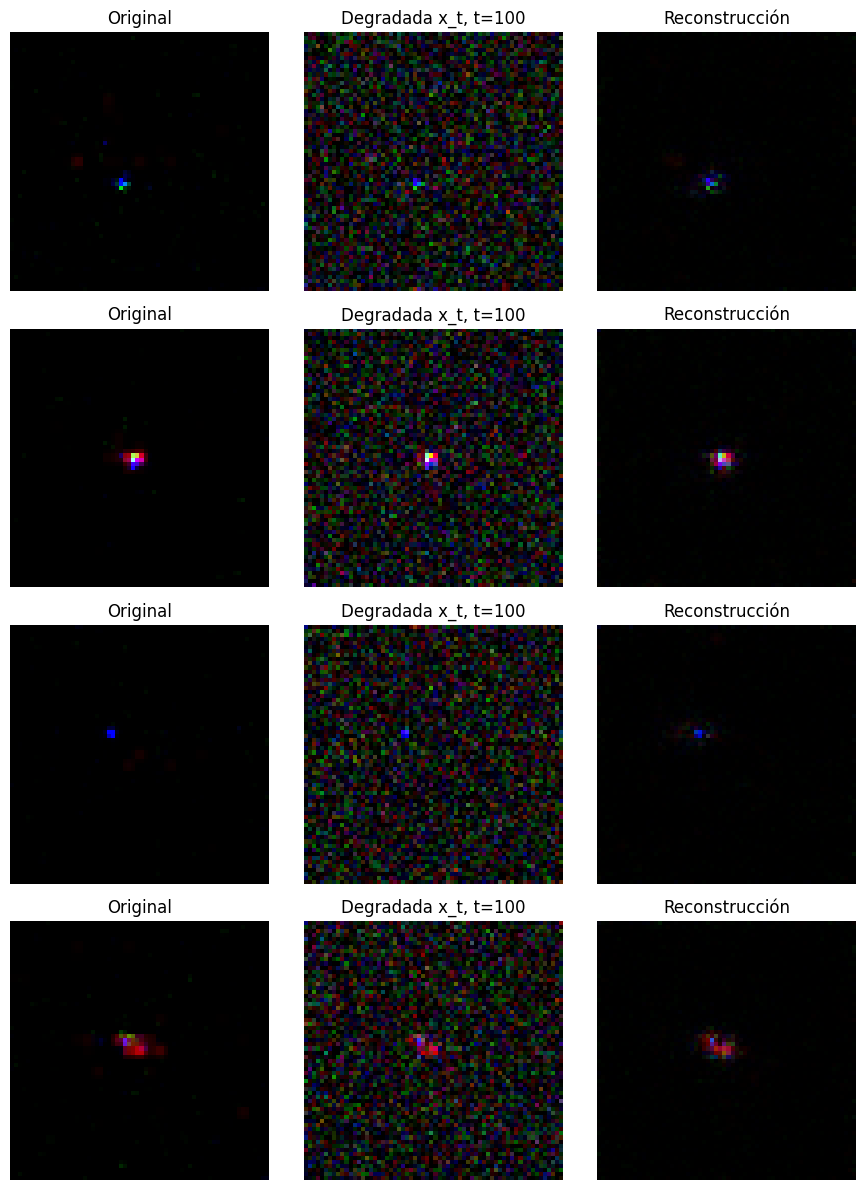

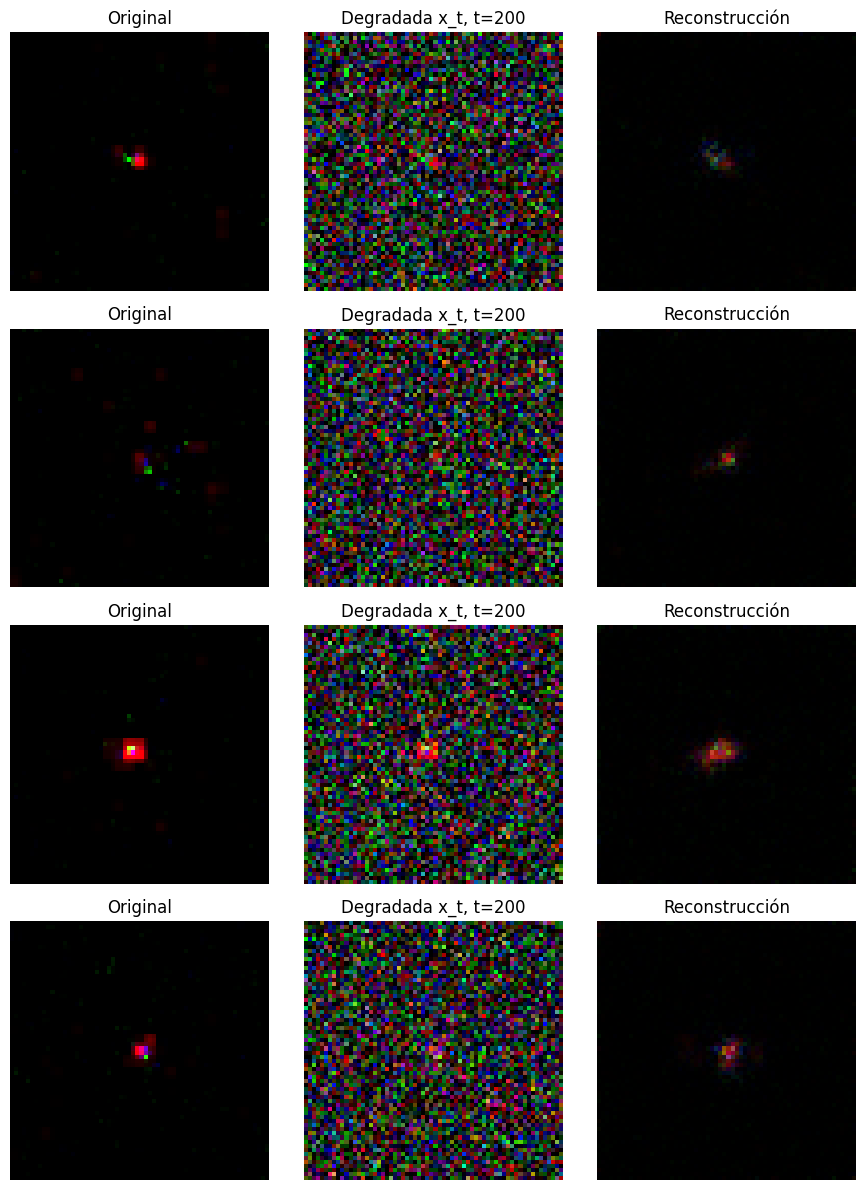

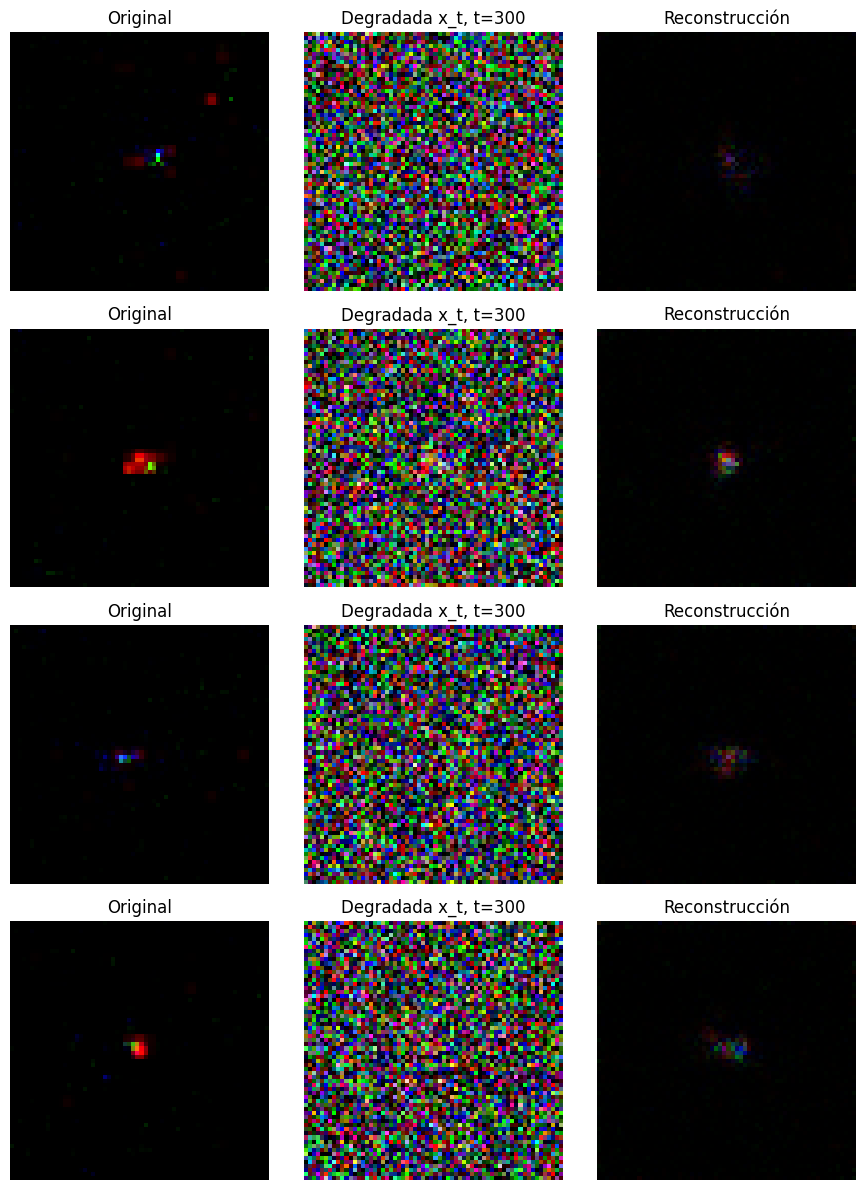

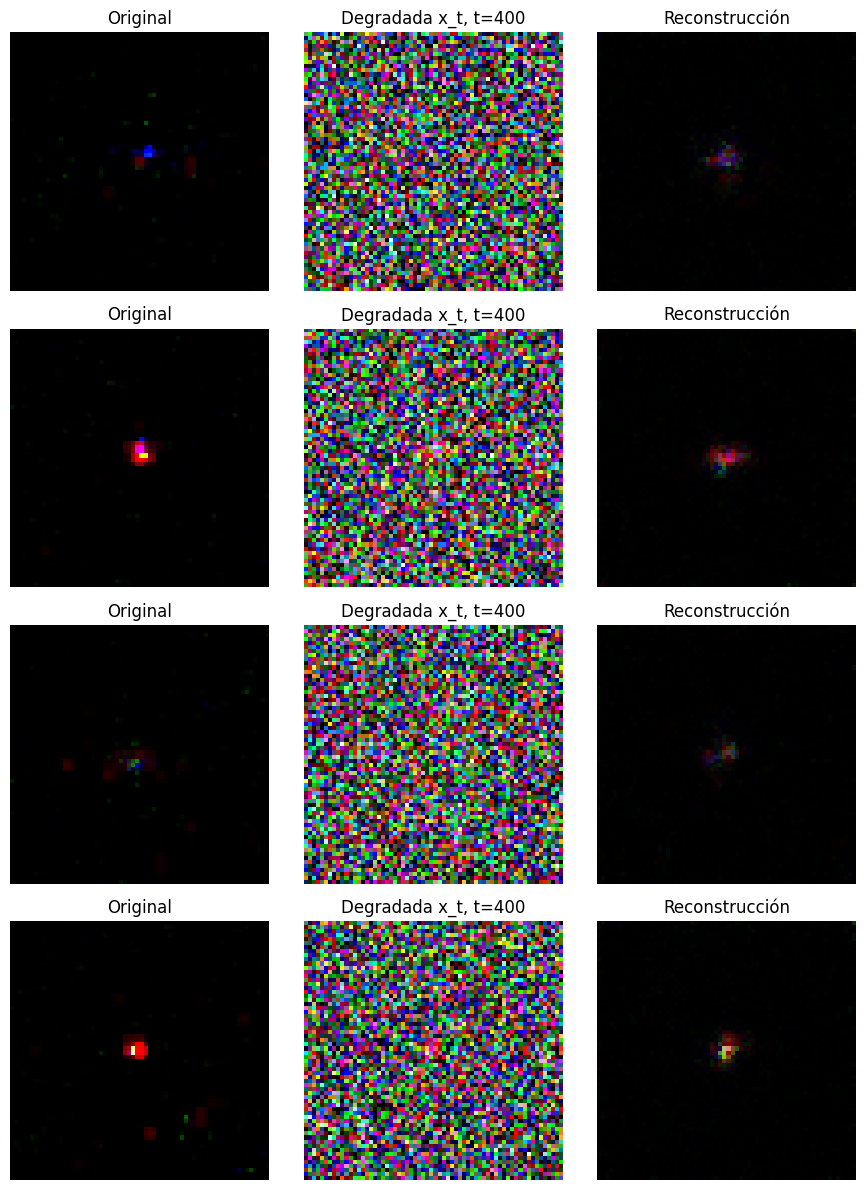

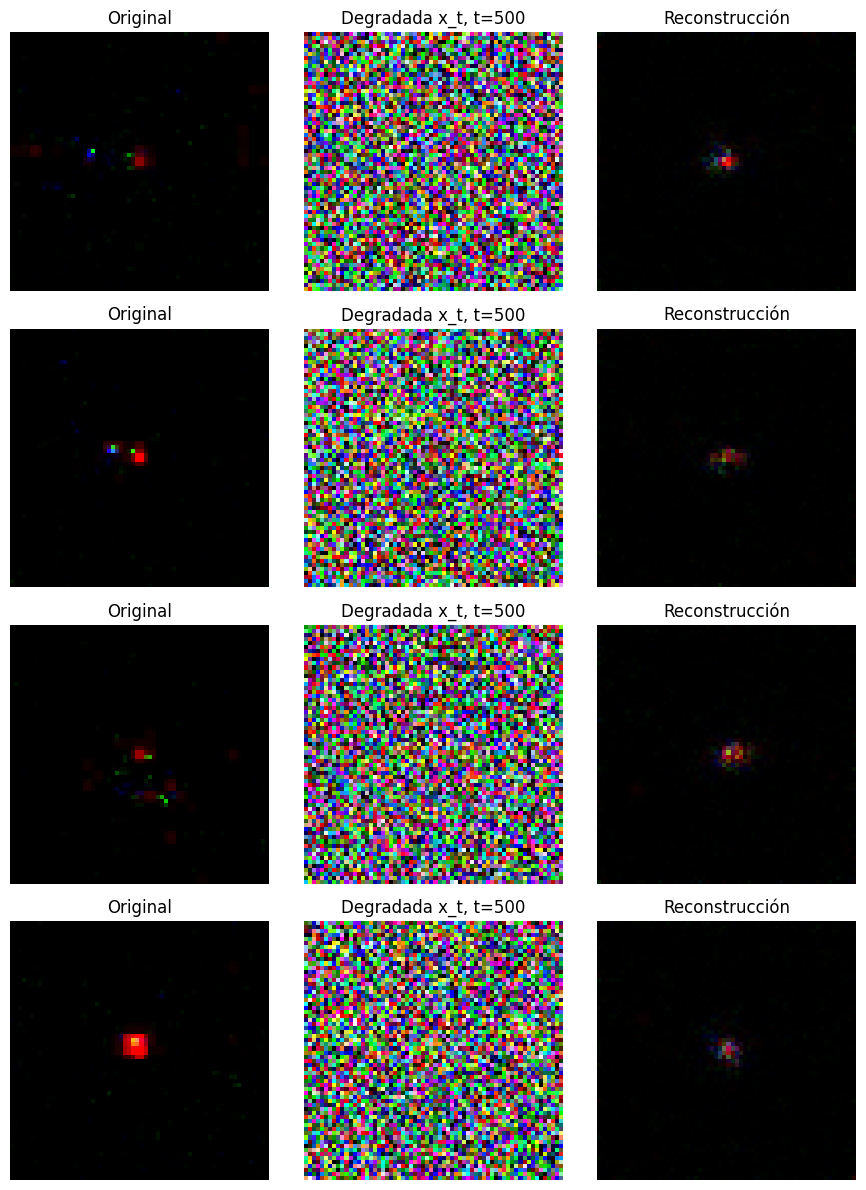

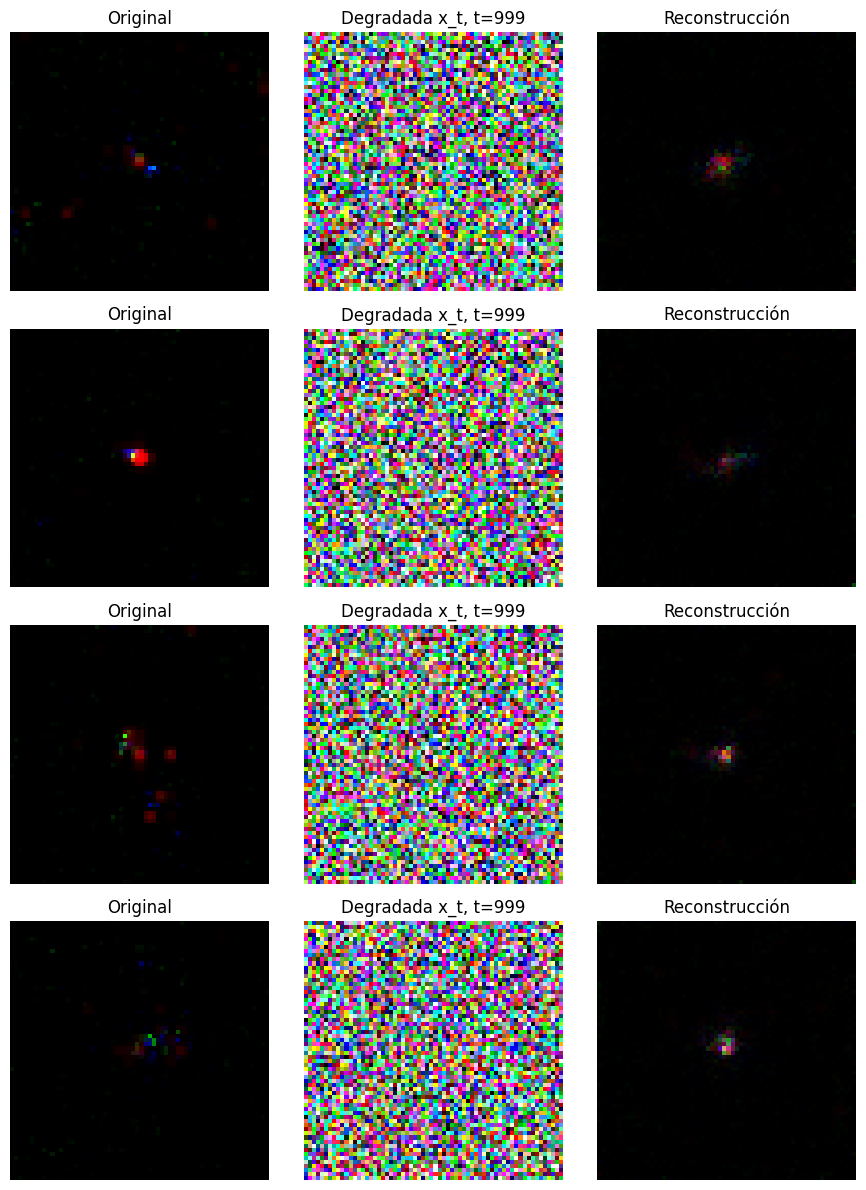

In [29]:
recon_50 = reconstruccion_iterativa_desde_xt_ddpm(
    modelo_entrenado,
    scheduler,
    train_loader,
    device,
    t_start=50,
    n=4
)

recon_100 = reconstruccion_iterativa_desde_xt_ddpm(
    modelo_entrenado,
    scheduler,
    train_loader,
    device,
    t_start=100,
    n=4
)

recon_200 = reconstruccion_iterativa_desde_xt_ddpm(
    modelo_entrenado,
    scheduler,
    train_loader,
    device,
    t_start=200,
    n=4
)

recon_300 = reconstruccion_iterativa_desde_xt_ddpm(
    modelo_entrenado,
    scheduler,
    train_loader,
    device,
    t_start=300,
    n=4
)

recon_400 = reconstruccion_iterativa_desde_xt_ddpm(
    modelo_entrenado,
    scheduler,
    train_loader,
    device,
    t_start=400,
    n=4
)

recon_500 = reconstruccion_iterativa_desde_xt_ddpm(
    modelo_entrenado,
    scheduler,
    train_loader,
    device,
    t_start=500,
    n=4
)

recon_1000 = reconstruccion_iterativa_desde_xt_ddpm(
    modelo_entrenado,
    scheduler,
    train_loader,
    device,
    t_start=999,
    n=4
)